# DNS ATTACK ANALYSIS

## 1. OBIETTIVO

Questo notebook ha lo scopo di effettuare una classificazione tra multiclassi di query DNS[normal, tunneling, dga, c2 e imposter] utilizzando tre tipologie di machine learning[random forest, catboost, MLP]. Successivamente verrà utilizzato come metro di paragone rispetto l'utilizzo di un LLM.

## 2. IMPORT

importiamo le librerie necessarie di python, preprocessing e model training

In [1]:
#3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#4
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#6
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score
#8
import os
import joblib

## 3. CARICAMENTO E ORGANIZZAZAIONE DEI DATI

- Caricamento dei dataset finali per ogni rispettivo attacco.
- Inserimento delle features nelle colonne del dataset.
- Classificazione delle classi.
- Concatenazione dei dataset in uno unico mescolato

In [2]:
df_dga = pd.read_json('OneDrive\\Desktop\\Tesi\\SESSIONE_VERA\\dga\\output_json\\analyze_data.json', lines=True)
df_tunnel = pd.read_json('OneDrive\\Desktop\\Tesi\\SESSIONE_VERA\\tunnel\\output_json\\analyze_data.json', lines=True)
df_imposter =  pd.read_json('OneDrive\\Desktop\\Tesi\\SESSIONE_VERA\\imposter\\output_json\\analyze_data.json', lines=True)

df_dga_feat = pd.json_normalize(df_dga['features'])
df_tunnel_feat = pd.json_normalize(df_tunnel['features'])
df_imposter_feat = pd.json_normalize(df_imposter['features'])

df_dga = pd.concat([df_dga_feat, df_dga[['query', 'label', 'qtype']]], axis=1)
df_tunnel = pd.concat([df_tunnel_feat, df_tunnel[['query', 'label', 'qtype']]], axis=1)
df_imposter = pd.concat([df_imposter_feat, df_imposter[['query', 'label', 'qtype']]], axis=1)

df_dga.loc[df_dga['label'] == 1, 'label'] = 2  # DGA
df_tunnel.loc[df_tunnel['label'] == 1, 'label'] = 1  # Tunneling
df_imposter.loc[df_imposter['label'] == 1, 'label'] = 3  # Imposter

df_final = pd.concat([df_dga, df_tunnel, df_imposter], ignore_index=True)

print(f"Righe prima della deduplicazione: {len(df_final)}")
df_final = df_final.drop_duplicates(subset=['query']).reset_index(drop=True)
print(f"Righe dopo la deduplicazione: {len(df_final)}")

df_final = df_final.sample(frac=1).reset_index(drop=True)

Righe prima della deduplicazione: 30521
Righe dopo la deduplicazione: 20155


In [3]:
#Prime 5 righe
print(df_final.head())

   len  entropy  digit_p  alpha_p  vowel_p  special_p  sub_count  max_cons  \
0   51    4.258    0.000    1.000    0.271      0.000          3        10   
1   27    3.574    0.500    0.455    0.182      0.045          5         3   
2   23    3.708    0.045    0.773    0.227      0.182          1         3   
3   51    4.432    0.000    1.000    0.250      0.000          3        11   
4   27    3.676    0.500    0.455    0.182      0.045          5         3   

                                               query  label qtype  
0  ioozzikqypbidpwcxcpmdbaihtmfog.sandbox.alphaso...      1   TXT  
1                        243.242.49.190.in-addr.arpa      0  AAAA  
2                            xn--prothn-alo-cx3e.com      3     A  
3  baokzxijengjdfejydnmcyvndqersu.sandbox.alphaso...      1   TXT  
4                        134.86.126.174.in-addr.arpa      0  AAAA  


In [4]:
#scrive colonne
print(df_final.columns)

Index(['len', 'entropy', 'digit_p', 'alpha_p', 'vowel_p', 'special_p',
       'sub_count', 'max_cons', 'query', 'label', 'qtype'],
      dtype='str')


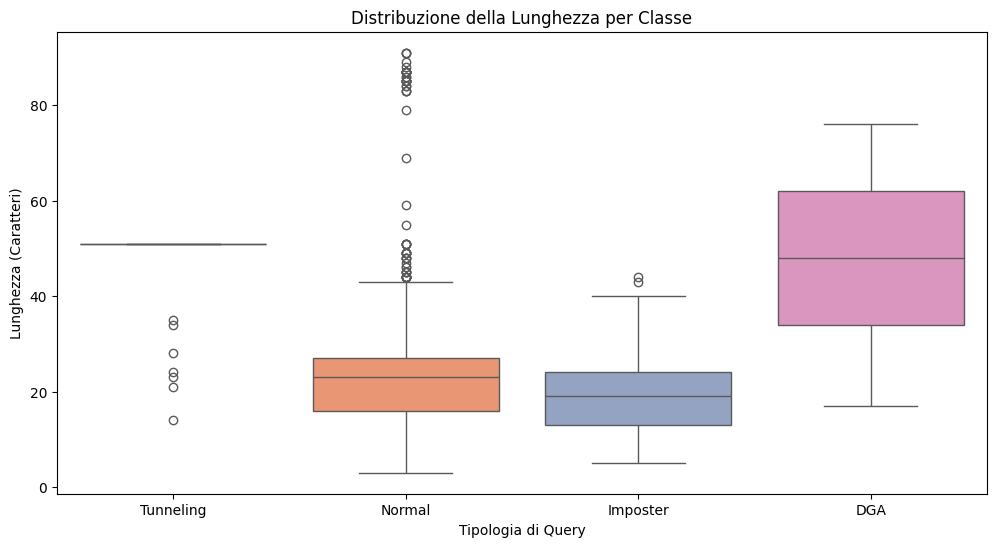

In [5]:
label_map = {0: 'Normal', 1: 'Tunneling', 2: 'DGA', 3:'Imposter'}
df_plot = df_final.copy()
df_plot['Nome_Attacco'] = df_plot['label'].map(label_map)

# Distribuzione della lunghezza per ogni classe
plt.figure(figsize=(12,6))
sns.boxplot(x='Nome_Attacco', y='len', hue="Nome_Attacco", data=df_plot, palette='Set2')
plt.title("Distribuzione della Lunghezza per Classe")
plt.xlabel("Tipologia di Query")
plt.ylabel("Lunghezza (Caratteri)")
plt.show()

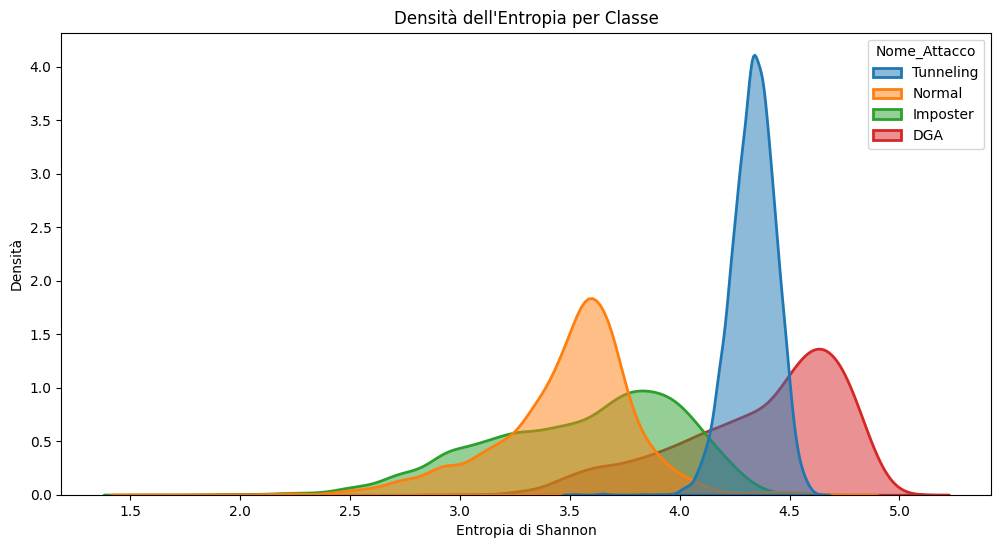

In [6]:
# Distribuzione dell'entropia per ogni classe
plt.figure(figsize=(12,6))
sns.kdeplot(
    data=df_plot, 
    x='entropy', 
    hue='Nome_Attacco', 
    fill=True, 
    palette='tab10', 
    common_norm=False, 
    alpha=0.5,
    linewidth=2
)
plt.title("Densità dell'Entropia per Classe")
plt.xlabel("Entropia di Shannon")
plt.ylabel("Densità")
plt.show()

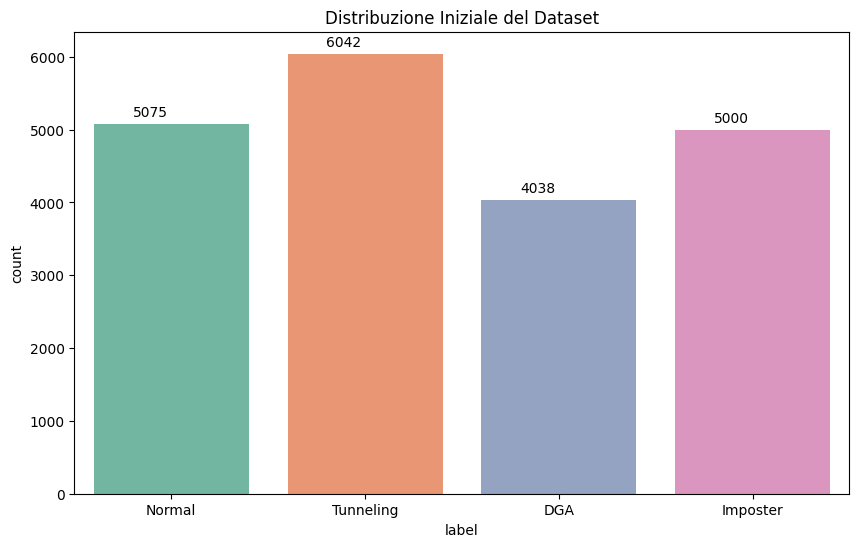

In [7]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x='label', data=df_final, hue='label', palette='Set2', legend=False)
plt.title('Distribuzione Iniziale del Dataset')
plt.xticks(ticks=[0,1,2,3], labels=['Normal', 'Tunneling', 'DGA', 'Imposter'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.2, p.get_height()+100))
plt.show()

## 4. SELEZIONE FEATURE

Gestione delle feature

In [14]:
# 1. Definiamo le feature numeriche base (come avevi già fatto)
numeric_features = ['len', 'entropy', 'digit_p', 'alpha_p', 'vowel_p', 'special_p', 'sub_count', 'max_cons']

# 2. Creiamo una copia del dataframe per non rovinare l'originale
df_ml = df_final.copy()

# 3. ONE-HOT ENCODING: Trasformiamo la colonna testuale 'qtype' in colonne numeriche 0/1
df_ml = pd.get_dummies(df_ml, columns=['qtype'], prefix='qtype', dtype=int)

# 4. Ora la nostra lista di features da dare in pasto al modello deve includere anche le nuove colonne generate!
# Prendiamo tutte le colonne base + tutte le nuove colonne che iniziano per 'qtype_'
final_features = numeric_features + [col for col in df_ml.columns if col.startswith('qtype_')]

print("Le feature finali per il Machine Learning sono:")
print(final_features)

# 5. Prepariamo X e y
X = df_ml[final_features]
y = df_ml['label']

Le feature finali per il Machine Learning sono:
['len', 'entropy', 'digit_p', 'alpha_p', 'vowel_p', 'special_p', 'sub_count', 'max_cons', 'qtype_A', 'qtype_AAAA', 'qtype_TXT']


Matrice di correlazione tra le features:

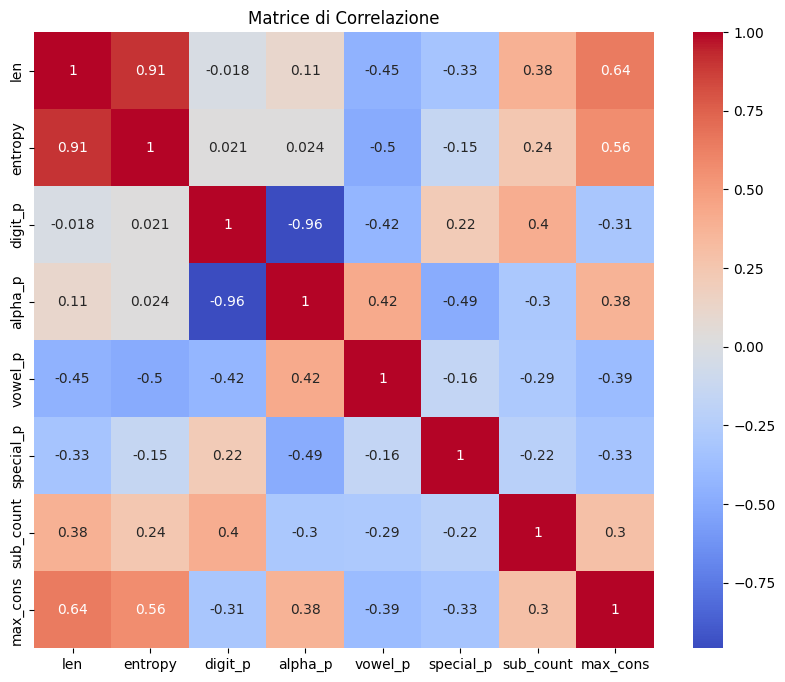

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df_final[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title('Matrice di Correlazione')
plt.show()

## 5. SPLITTING: TRAIN, VALIDATION E TEST

Splitting data in [Train-70%] [Val-15%] [Test-15%]

In [16]:
# Dati Originali (per CatBoost e RF)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Dati Scalati (per MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 6. MODEL TRAINING

### 6.1 RANDOM FOREST

In [17]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) 

y_pred_rf = rf_model.predict(X_test)

print("--- REPORT RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

--- REPORT RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       762
           1       1.00      1.00      1.00       907
           2       0.99      1.00      0.99       605
           3       0.87      0.90      0.89       750

    accuracy                           0.94      3024
   macro avg       0.94      0.94      0.94      3024
weighted avg       0.94      0.94      0.94      3024



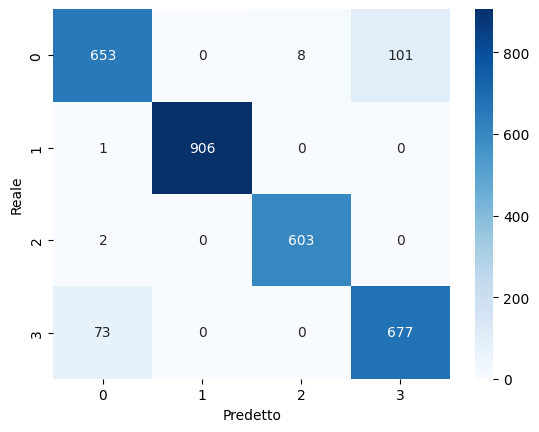

In [18]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.show()

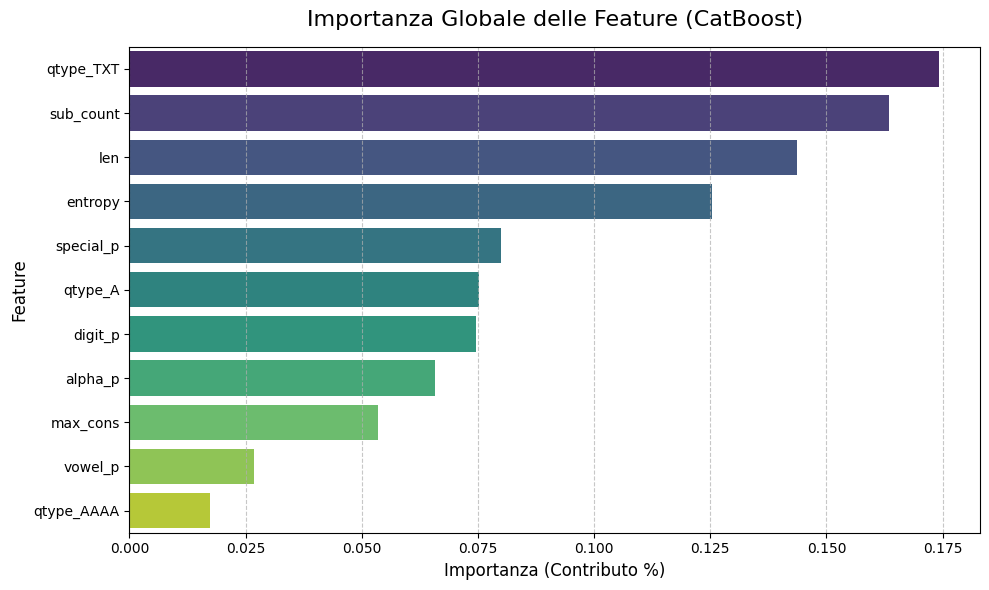

In [19]:
importances = rf_model.feature_importances_
nomi_feature = X_train.columns

df_importanza = pd.DataFrame({
    'Feature': nomi_feature,
    'Importanza': importances
})

df_importanza = df_importanza.sort_values(by='Importanza', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importanza', y='Feature', hue='Feature', data=df_importanza, palette='viridis')

plt.title('Importanza Globale delle Feature (CatBoost)', fontsize=16, pad=15)
plt.xlabel('Importanza (Contributo %)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

#plt.savefig('feature_importance_plot.png', dpi=300)

plt.show()

### 6.2 CATBOOST

In [20]:
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    eval_metric='Accuracy',
    verbose=100,
    early_stopping_rounds=50
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)

y_pred_cat = cat_model.predict(X_test)
print("--- REPORT CATBOOST  ---")
print(classification_report(y_test, y_pred_cat))

0:	learn: 0.8886447	test: 0.8954681	best: 0.8954681 (0)	total: 179ms	remaining: 2m 58s
100:	learn: 0.9486816	test: 0.9477340	best: 0.9483956 (85)	total: 1.73s	remaining: 15.4s
200:	learn: 0.9520839	test: 0.9490572	best: 0.9493880 (193)	total: 3.23s	remaining: 12.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9493880251
bestIteration = 193

Shrink model to first 194 iterations.
--- REPORT CATBOOST  ---
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       762
           1       1.00      1.00      1.00       907
           2       0.99      0.99      0.99       605
           3       0.87      0.93      0.90       750

    accuracy                           0.94      3024
   macro avg       0.94      0.94      0.94      3024
weighted avg       0.94      0.94      0.94      3024



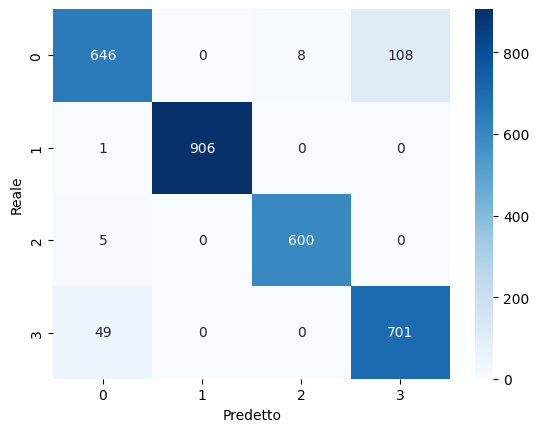

In [21]:
cm = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.show()

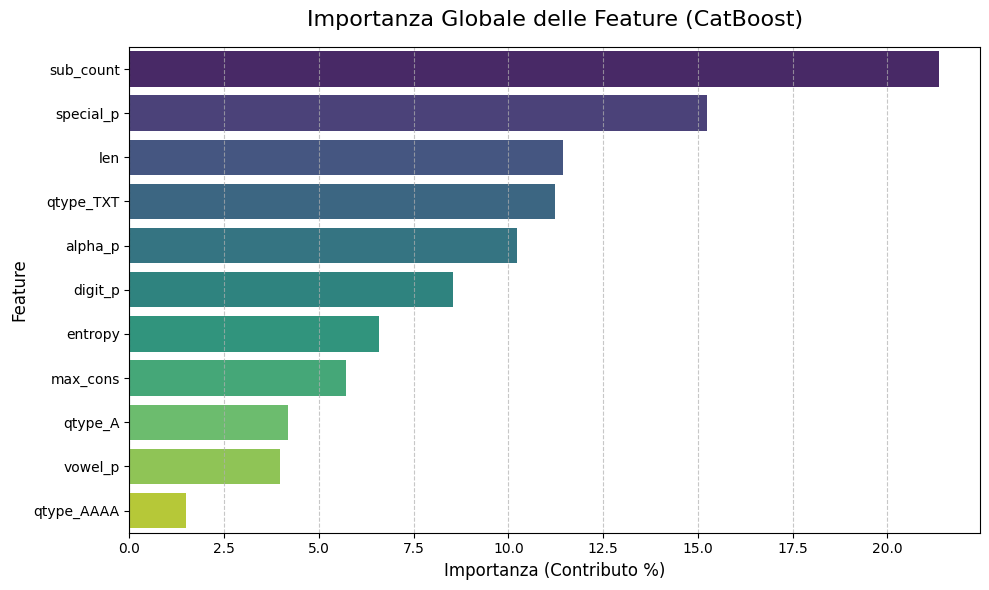

In [22]:
importances = cat_model.get_feature_importance()
nomi_feature = X_train.columns

df_importanza = pd.DataFrame({
    'Feature': nomi_feature,
    'Importanza': importances
})

df_importanza = df_importanza.sort_values(by='Importanza', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importanza', y='Feature', hue='Feature', data=df_importanza, palette='viridis')

plt.title('Importanza Globale delle Feature (CatBoost)', fontsize=16, pad=15)
plt.xlabel('Importanza (Contributo %)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

#plt.savefig('feature_importance_plot.png', dpi=300)

plt.show()

### 6.3 MLP

In [23]:
# rete neurale (2 livelli nascosti da 64 e 32 neuroni)
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)

print("--- REPORT MLP ---")
print(classification_report(y_test, y_pred_mlp))

--- REPORT MLP ---
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       762
           1       1.00      1.00      1.00       907
           2       0.99      0.99      0.99       605
           3       0.86      0.94      0.90       750

    accuracy                           0.94      3024
   macro avg       0.94      0.94      0.94      3024
weighted avg       0.94      0.94      0.94      3024



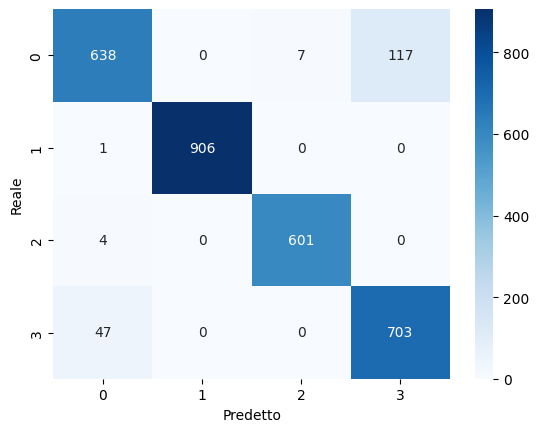

In [24]:
cm = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.show()

## 7. CONFRONTO

In [25]:
models_comparison = pd.DataFrame({
    'Modello': ['Random Forest', 'CatBoost', 'MLP (Rete Neurale)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_cat),
        accuracy_score(y_test, y_pred_mlp)
    ],
    'F1-Score (Macro)': [
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_cat, average='macro'),
        f1_score(y_test, y_pred_mlp, average='macro')
    ]
})
print("--- COMPARAZIONE MODELLI ---")
print(models_comparison)

--- COMPARAZIONE MODELLI ---
              Modello  Accuracy  F1-Score (Macro)
0       Random Forest  0.938823          0.938318
1            CatBoost  0.943452          0.942786
2  MLP (Rete Neurale)  0.941799          0.941177


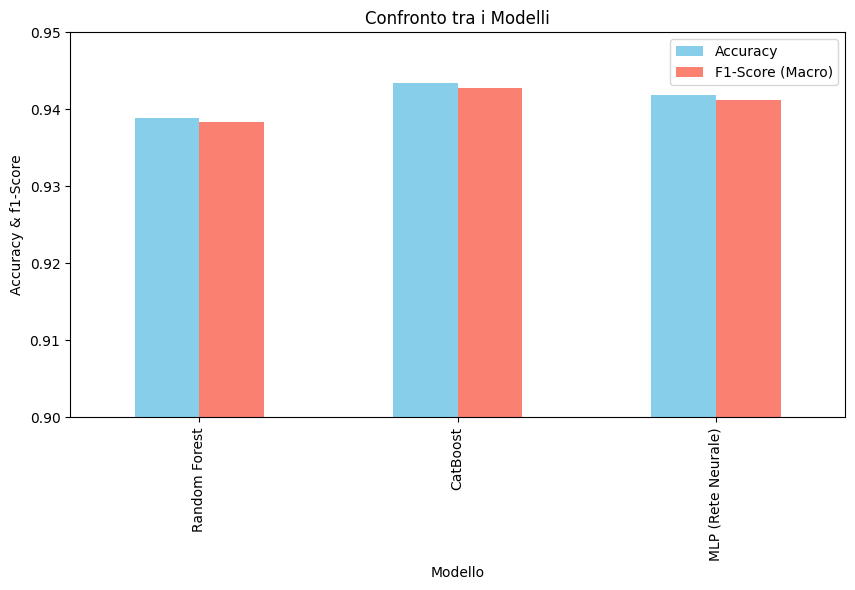

In [26]:
models_comparison.plot(kind='bar', x='Modello', figsize=(10,5), color=['skyblue', 'salmon', 'lightgreen'])
plt.ylim(0.90, 0.95)
plt.title('Confronto tra i Modelli')
plt.ylabel('Accuracy & f1-Score')
plt.show()

## 8. ESPORTAZIONE MODELLI E PREPROCESSING

In [21]:
export_dir = "OneDrive\\Desktop\\Tesi\\exports_tesi"
os.makedirs(export_dir, exist_ok=True)


joblib.dump(rf_model, f"{export_dir}/random_forest_model.pkl")
joblib.dump(mlp_model, f"{export_dir}/mlp_model.pkl")
cat_model.save_model(f"{export_dir}/catboost_model.cbm")

joblib.dump(scaler, f"{export_dir}/standard_scaler.pkl")

joblib.dump(numeric_features, f"{export_dir}/feature_names.pkl")

label_map = {0: 'Normal', 1: 'Tunneling', 2: 'DGA', 3: 'Imposter'}
joblib.dump(label_map, f"{export_dir}/label_map.pkl")

print(f"Esportazione completata con successo")

Esportazione completata con successo
